# ĐỀ THI THỰC HÀNH HỌC KỲ 252 – NĂM HỌC 2025–2026  
**Môn:** Thị giác máy tính  
**Trường:** Đại học VĂN LANG  
**Khoa:** CÔNG NGHỆ THÔNG TIN  
**Ngày thi:** 03/04/2026  
**Thời gian:** 120 phút  

> (Được phép sử dụng tài liệu và laptop kết nối mạng)

**Họ tên:** Phạm Huỳnh Tấn
**MSSV:** 2374802013448   
**LỚP:** 0101

## Bài 1 (1 điểm)
Trình bày những nội dung cơ bản của **phép biến đổi Hough**. Lấy ví dụ thực hành (bao gồm code python)

Khái Niệm Cơ Bản

Phép biến đổi Hough là một kỹ thuật xử lý ảnh mạnh mẽ dùng để phát hiện các hình dạng hình học (đường thẳng, hình tròn, ellipse, v.v.) trong ảnh. Nó hoạt động bằng cách chuyển đổi các điểm trong không gian ảnh sang một không gian tham số.

Biến Đổi Hough cho Đường Thẳng : p = xcosθ + ysinθ

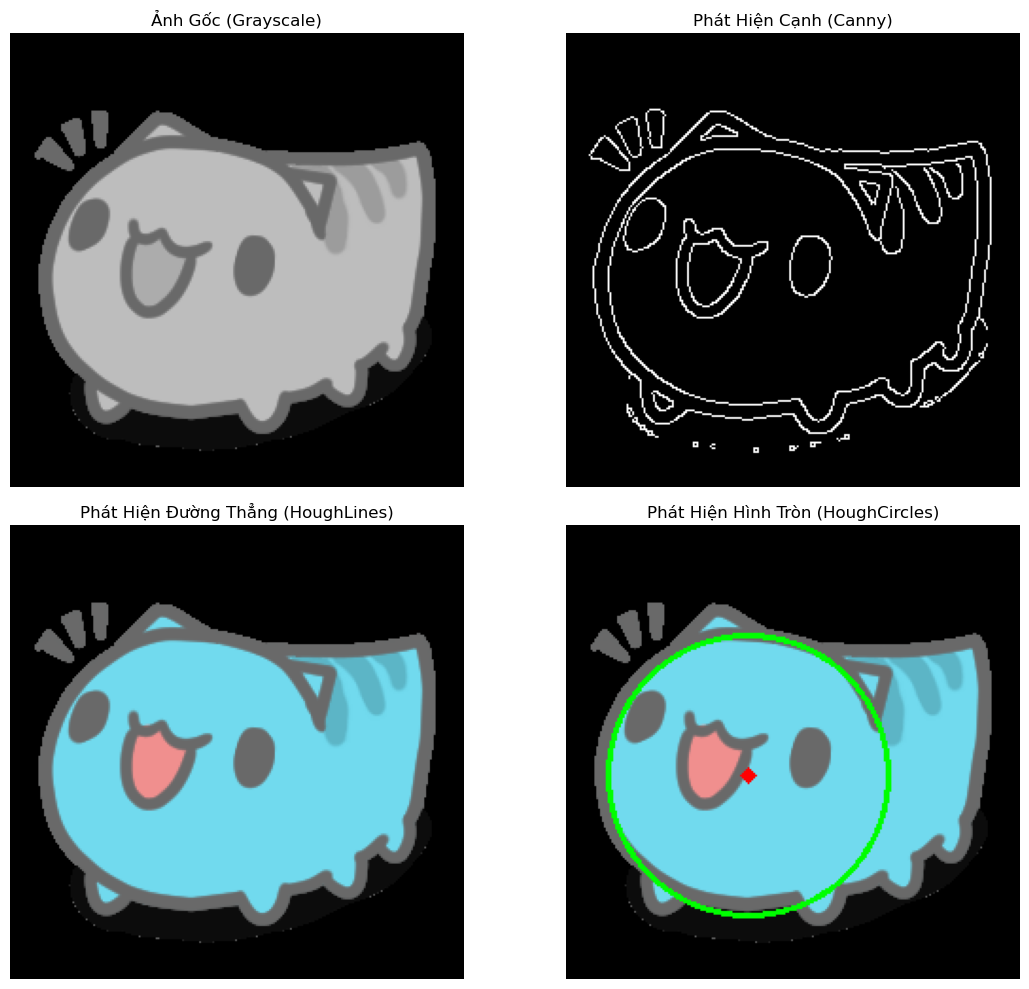

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ===== 1. PHÁT HIỆN ĐƯỜNG THẲNG =====

# Đọc ảnh
img = cv2.imread('cat.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Phát hiện cạnh bằng Canny
edges = cv2.Canny(gray, 50, 150)

# Áp dụng Hough Line Transform
# HoughLines: trả về các dòng ở dạng (rho, theta)
lines = cv2.HoughLines(edges, 1, np.pi/180, 100)

# Vẽ các đường thẳng tìm được
img_lines = img.copy()
if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        
        # Tính điểm đầu và cuối của đường thẳng
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * a)
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * a)
        
        cv2.line(img_lines, (x1, y1), (x2, y2), (0, 0, 255), 2)

# ===== 2. PHÁT HIỆN HÌNH TRÒN =====

# Đối với hình tròn, sử dụng HoughCircles
circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1,              # tỷ lệ độ phân giải
    minDist=100,       # khoảng cách tối thiểu giữa các hình tròn
    param1=50,         # ngưỡng Canny
    param2=30,         # ngưỡng tích lũy
    minRadius=10,      # bán kính tối thiểu
    maxRadius=200      # bán kính tối đa
)

img_circles = img.copy()
if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        center = (i[0], i[1])
        radius = i[2]
        
        # Vẽ hình tròn
        cv2.circle(img_circles, center, radius, (0, 255, 0), 2)
        # Vẽ tâm
        cv2.circle(img_circles, center, 2, (0, 0, 255), 3)

# ===== 3. HOUGH LINES P (với trả về điểm đầu-cuối) =====

lines_p = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi/180,
    threshold=50,
    minLineLength=30,   # độ dài tối thiểu
    maxLineGap=10       # khoảng cách tối đa giữa các đoạn
)

img_lines_p = img.copy()
if lines_p is not None:
    for line in lines_p:
        x1, y1, x2, y2 = line[0]
        cv2.line(img_lines_p, (x1, y1), (x2, y2), (255, 0, 0), 2)

# ===== 4. HIỂN THỊ KẾT QUẢ =====

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB))
axes[0, 0].set_title('Ảnh Gốc (Grayscale)')
axes[0, 0].axis('off')

axes[0, 1].imshow(cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB))
axes[0, 1].set_title('Phát Hiện Cạnh (Canny)')
axes[0, 1].axis('off')

axes[1, 0].imshow(cv2.cvtColor(img_lines, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('Phát Hiện Đường Thẳng (HoughLines)')
axes[1, 0].axis('off')

axes[1, 1].imshow(cv2.cvtColor(img_circles, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Phát Hiện Hình Tròn (HoughCircles)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## Bài 2 (1 điểm)
Trình bày những nội dung cơ bản của phương pháp nhận dạng khuôn mặt **Viola – Jones**. Lấy ví dụ thực hành (bao gồm code python) -Note: Kiểm tra khả năng tự học

Viola-Jones là một thuật toán nhận dạng khuôn mặt được công bố bởi Paul Viola và Michael Jones vào năm 2001. Đây là một trong những phương pháp đầu tiên cho phép phát hiện khuôn mặt real-time với độ chính xác cao.

Các Thành Phần Cốt Lõi:
- Integral Image (Ảnh Tích Lũy)
- Haar Features (Đặc Trưng Haar)
- AdaBoost (Adaptive Boosting)
- Cascade Classifiers (Bộ Phân Loại Tầng)
Quy trình hoạt động 
Input: Image -> Tính Integral Image -> Tính Haar Features -> Cascade Classifier : Stage 1 , Stage 2 , ... Stage N -> Output: Face Detections



Phát hiện được 4 khuôn mặt trong ảnh.


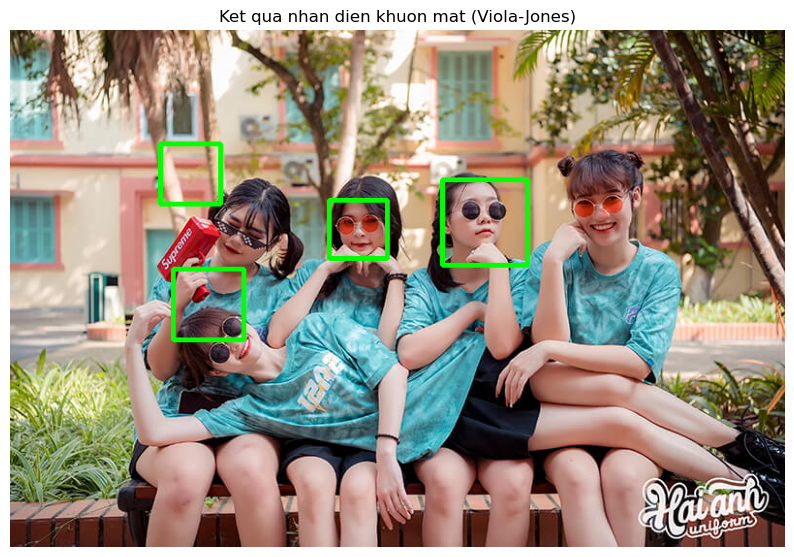

In [4]:
# Import các thư viện cần thiết
import cv2
import matplotlib.pyplot as plt

# 1. Tải bộ phân loại Haar Cascade đã được huấn luyện sẵn cho khuôn mặt
# File xml này được tích hợp sẵn trong thư viện cv2
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# 2. Đọc hình ảnh đầu vào (Thay 'duong_dan_anh_cua_ban.jpg' bằng file ảnh thực tế của bạn)
# Ví dụ: image = cv2.imread('test_image.jpg')
image_path = 'people.jpg' # BẠN CẦN ĐỔI TÊN FILE TẠI ĐÂY
image = cv2.imread(image_path)

# Kiểm tra xem ảnh có tồn tại không
if image is None:
    print("Không tìm thấy hình ảnh! Vui lòng kiểm tra lại đường dẫn.")
else:
    # 3. Chuyển đổi ảnh màu sang ảnh xám (Grayscale)
    # Viola-Jones hoạt động trên ảnh xám để tính toán các đặc trưng Haar
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 4. Thực hiện phát hiện khuôn mặt
    # - scaleFactor: Hệ số tỷ lệ bù đắp cho việc khuôn mặt có thể lớn/nhỏ khác nhau
    # - minNeighbors: Số lượng ô lân cận tối thiểu cần giữ lại (giúp giảm nhiễu)
    faces = face_cascade.detectMultiScale(
        gray_image, 
        scaleFactor=1.1, 
        minNeighbors=5, 
        minSize=(30, 30) # Kích thước khuôn mặt nhỏ nhất để quét
    )

    print(f"Phát hiện được {len(faces)} khuôn mặt trong ảnh.")

    # 5. Vẽ hình chữ nhật bao quanh các khuôn mặt phát hiện được
    for (x, y, w, h) in faces:
        # cv2.rectangle(ảnh, điểm_bắt_đầu, điểm_kết_thúc, màu_sắc_BGR, độ_dày_nét_vẽ)
        cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 3)

    # 6. Chuyển đổi hệ màu BGR (OpenCV) sang RGB (Matplotlib) để hiển thị đúng màu
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Hiển thị ảnh bằng Matplotlib ngay trong Jupyter Notebook
    plt.figure(figsize=(10, 8))
    plt.imshow(image_rgb)
    plt.axis('off') # Tắt trục tọa độ
    plt.title('Ket qua nhan dien khuon mat (Viola-Jones)')
    plt.show()

## Bài 3 (1 điểm)
So sánh thuật toán **Meanshift** và **Camshift**. Lấy ví dụ minh họa kèm code python -Note: Kiểm tra khả năng tự học

Cả hai đều là những thuật toán phổ biến trong thị giác máy tính dùng để theo dõi đối tượng (object tracking) dựa trên phân tích biểu đồ màu (color histogram) và thuật toán dịch chuyển trung bình. Tuy nhiên, Camshift ra đời để khắc phục những điểm yếu chí mạng của Meanshift.

Điểm chung:
Đều sử dụng biểu đồ màu (thường là không gian màu HSV) để mô hình hóa đối tượng.

Sử dụng kỹ thuật Back Projection (Chiếu ngược) để tạo ra một bản đồ xác suất, trong đó các pixel có màu giống với đối tượng sẽ sáng lên.

Đều lặp lại quá trình tìm "trọng tâm" (center of mass) của vùng có mật độ xác suất cao nhất và dịch chuyển cửa sổ theo dõi (search window) về trọng tâm đó cho đến khi hội tụ.

Điểm khác biệt: 
- Kích thước cửa sổ
- Xử lý khoảng cách
- Góc quay (Orientation/Rotation)
- Tốc độ tính toán

MeanShift Tracking

In [16]:
import cv2

cap = cv2.VideoCapture(0)

# Lấy thông số video
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
fps = 20

# Khởi tạo VideoWriter
out = cv2.VideoWriter(
    'meanshift_output.avi',
    cv2.VideoWriter_fourcc(*'XVID'),
    fps,
    (frame_width, frame_height)
)

ret, frame = cap.read()

# ROI ban đầu
x, y, w, h = 300, 200, 100, 100
track_window = (x, y, w, h)

roi = frame[y:y+h, x:x+w]
hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

roi_hist = cv2.calcHist([hsv_roi], [0], None, [180], [0,180])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)

term_crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    back_proj = cv2.calcBackProject([hsv], [0], roi_hist, [0,180], 1)

    _, track_window = cv2.meanShift(back_proj, track_window, term_crit)

    x, y, w, h = track_window
    cv2.rectangle(frame, (x,y), (x+w,y+h), (0,255,0), 2)

    # 🔥 GHI FRAME
    out.write(frame)

    cv2.imshow('MeanShift', frame)
    if cv2.waitKey(30) & 0xFF == 27:
        break

cap.release()
out.release()
cv2.destroyAllWindows()

CamShift Tracking

In [17]:
import cv2

cap = cv2.VideoCapture(0)

frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
fps = 20

out = cv2.VideoWriter(
    'camshift_output.avi',
    cv2.VideoWriter_fourcc(*'XVID'),
    fps,
    (frame_width, frame_height)
)

ret, frame = cap.read()

x, y, w, h = 300, 200, 100, 100
track_window = (x, y, w, h)

roi = frame[y:y+h, x:x+w]
hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

roi_hist = cv2.calcHist([hsv_roi], [0], None, [180], [0,180])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)

term_crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    back_proj = cv2.calcBackProject([hsv], [0], roi_hist, [0,180], 1)

    ret, track_window = cv2.CamShift(back_proj, track_window, term_crit)

    pts = cv2.boxPoints(ret)
    pts = pts.astype(int)

    cv2.polylines(frame, [pts], True, (0,255,0), 2)

    # 🔥 GHI FRAME
    out.write(frame)

    cv2.imshow('CamShift', frame)
    if cv2.waitKey(30) & 0xFF == 27:
        break

cap.release()
out.release()
cv2.destroyAllWindows()

## Bài 4 (2 điểm)

Cho ảnh 3-bit kích thước $5 \times 5$, bộ lọc thông thấp và bộ lọc Laplacian như hình vẽ.

Thực hiện tại điểm ảnh $(2,1)$ cho ảnh gốc, xác định:

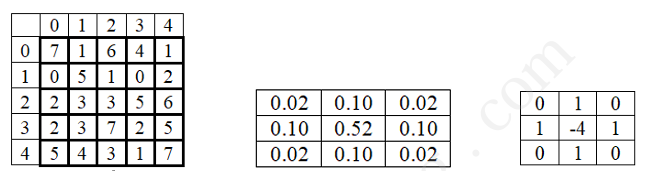

a. Giá trị sau khi áp dụng bộ lọc trung bình $3 \times 3$  
b. Giá trị sau khi áp dụng bộ lọc trung vị $3 \times 3$  
c. Giá trị sau khi áp dụng bộ lọc Laplacian  
d. Giá trị sau khi áp dụng bộ lọc thông thấp  
e. Xác định $dx, dy$  
f. Vẽ histogram của ảnh gốc  
g. Xác định ảnh sau khi cân bằng histogram

- a
Tổng: 0 + 5 + 1 + 2 + 3 + 3 + 2 + 3 + 7 = 26

Trung bình: 26 / 9 = 2.89

Kết quả: Làm tròn thành 3.
- b
Mảng sau khi sắp xếp tăng dần: 0, 1, 2, 2, 3, 3, 3, 5, 7

Kết quả: Giá trị ở vị trí thứ 5 (chính giữa) là 3.
- c
Phép tính: (0 * 0) + (1 * 5) + (0 * 1) + (1 * 2) + (-4 * 3) + (1 * 3) + (0 * 2) + (1 * 3) + (0 * 7)

Kết quả: 0 + 5 + 0 + 2 - 12 + 3 + 0 + 3 + 0 = 1.
- d 
Phép tính: (0.02 * 0) + (0.10 * 5) + (0.02 * 1) + (0.10 * 2) + (0.52 * 3) + (0.10 * 3) + (0.02 * 2) + (0.10 * 3) + (0.02 * 7)

Kết quả: 0 + 0.5 + 0.02 + 0.2 + 1.56 + 0.3 + 0.04 + 0.3 + 0.14 = 3.06 (làm tròn thành 3).
- e 
Đạo hàm theo chiều ngang (dx): f(y, x+1) - f(y, x-1) = f(2, 2) - f(2, 0) = 3 - 2 = 1

Đạo hàm theo chiều dọc (dy): f(y+1, x) - f(y-1, x) = f(3, 1) - f(1, 1) = 3 - 5 = -2


f & g 

--- MA TRẬN ẢNH GỐC ---
[[7 1 6 4 1]
 [0 5 1 0 2]
 [2 3 3 5 6]
 [2 3 7 2 5]
 [5 4 3 1 7]]
------------------------------

--- TẦN SUẤT XUẤT HIỆN (HISTOGRAM) ---
Mức xám 0: 2 điểm ảnh
Mức xám 1: 4 điểm ảnh
Mức xám 2: 4 điểm ảnh
Mức xám 3: 4 điểm ảnh
Mức xám 4: 2 điểm ảnh
Mức xám 5: 4 điểm ảnh
Mức xám 6: 2 điểm ảnh
Mức xám 7: 3 điểm ảnh


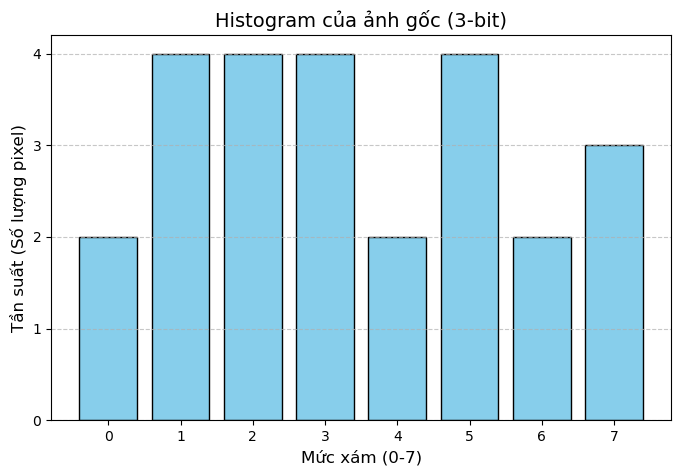


--- BẢNG ÁNH XẠ CÂN BẰNG HISTOGRAM ---
Mức xám gốc (r_k) -> Mức xám mới (s_k)
       0          ->        1
       1          ->        2
       2          ->        3
       3          ->        4
       4          ->        4
       5          ->        6
       6          ->        6
       7          ->        7

--- ẢNH SAU KHI CÂN BẰNG HISTOGRAM ---
[[7 2 6 4 2]
 [1 6 2 1 3]
 [3 4 4 6 6]
 [3 4 7 3 6]
 [6 4 4 2 7]]


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Khởi tạo ma trận ảnh gốc 5x5 từ đề bài
# Lưu ý: Hàng và cột ngoài cùng trong ảnh của đề bài chỉ là index (0->4)
image = np.array([
    [7, 1, 6, 4, 1],
    [0, 5, 1, 0, 2],
    [2, 3, 3, 5, 6],
    [2, 3, 7, 2, 5],
    [5, 4, 3, 1, 7]
])

print("--- MA TRẬN ẢNH GỐC ---")
print(image)
print("-" * 30)

# ==========================================
# CÂU f: VẼ HISTOGRAM CỦA ẢNH GỐC
# ==========================================
L = 8 # Ảnh 3-bit có 2^3 = 8 mức xám (từ 0 đến 7)
levels = np.arange(L)

# Tính tần suất (histogram) cho từng mức xám từ 0 đến 7
hist, _ = np.histogram(image.flatten(), bins=L, range=(0, L))

print("\n--- TẦN SUẤT XUẤT HIỆN (HISTOGRAM) ---")
for i in levels:
    print(f"Mức xám {i}: {hist[i]} điểm ảnh")

# Vẽ biểu đồ Histogram
plt.figure(figsize=(8, 5))
plt.bar(levels, hist, color='skyblue', edgecolor='black')
plt.title('Histogram của ảnh gốc (3-bit)', fontsize=14)
plt.xlabel('Mức xám (0-7)', fontsize=12)
plt.ylabel('Tần suất (Số lượng pixel)', fontsize=12)
plt.xticks(levels)
plt.yticks(np.arange(0, max(hist) + 1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show() # Hiển thị biểu đồ


# ==========================================
# CÂU g: XÁC ĐỊNH ẢNH SAU KHI CÂN BẰNG HISTOGRAM
# ==========================================
total_pixels = image.size # Tổng số điểm ảnh (5x5 = 25)

# 1. Tính xác suất (PDF - Probability Density Function)
pdf = hist / total_pixels

# 2. Tính xác suất tích lũy (CDF - Cumulative Distribution Function)
cdf = np.cumsum(pdf)

# 3. Tính giá trị mức xám mới s_k = round((L - 1) * CDF)
s_k = np.round((L - 1) * cdf).astype(int)

# In bảng ánh xạ mức xám để dễ theo dõi
print("\n--- BẢNG ÁNH XẠ CÂN BẰNG HISTOGRAM ---")
print("Mức xám gốc (r_k) -> Mức xám mới (s_k)")
mapping = {}
for i in range(L):
    mapping[i] = s_k[i]
    print(f"       {i}          ->        {s_k[i]}")

# 4. Áp dụng bảng ánh xạ để tạo ảnh mới
# np.vectorize giúp áp dụng một hàm lên từng phần tử của ma trận
equalized_image = np.vectorize(mapping.get)(image)

print("\n--- ẢNH SAU KHI CÂN BẰNG HISTOGRAM ---")
print(equalized_image)

## Bài 5 (1 điểm)

Cho ảnh nhị phân kích thước $6 \times 6$, trong đó các ô trống có giá trị 0.

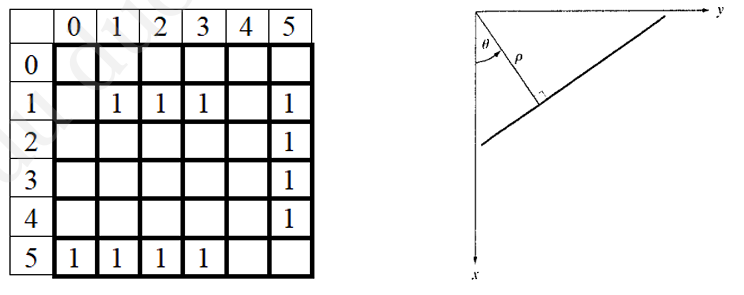

Xác định ma trận **accumulator cell**  $A(\rho,\theta)$. 
(xét các giá trị $\rho$ thích hợp và $\theta = 0^o, 45^o, 90^o$ ).

Từ bảng trên, ta đếm số lần xuất hiện (bình chọn - vote) của từng giá trị $\rho$ tại mỗi góc $\theta$ để hình thành các ô tích lũy (Accumulator cells) khác $0$:

Tại góc $\theta = 0^\circ$: (Phát hiện đường nằm ngang) /
- $A(1, 0^\circ) = \mathbf{4}$ (Đường thẳng đi qua hàng 1) 
- $A(2, 0^\circ) = \mathbf{1}$
- $A(3, 0^\circ) = \mathbf{1}$
- $A(4, 0^\circ) = \mathbf{1}$
- $A(5, 0^\circ) = \mathbf{4}$ (Đường thẳng đi qua hàng 5)

Tại góc $\theta = 90^\circ$: (Phát hiện đường thẳng đứng)
- $A(0, 90^\circ) = \mathbf{1}$
- $A(1, 90^\circ) = \mathbf{2}$
- $A(2, 90^\circ) = \mathbf{2}$
- $A(3, 90^\circ) = \mathbf{2}$
- $A(5, 90^\circ) = \mathbf{4}$ (Đường thẳng đi qua cột 5)

Tại góc $\theta = 45^\circ$:
- $A(1.0\sqrt{2}, 45^\circ) = \mathbf{1}$
- $A(1.5\sqrt{2}, 45^\circ) = \mathbf{1}$
- $A(2.0\sqrt{2}, 45^\circ) = \mathbf{1}$
- $A(2.5\sqrt{2}, 45^\circ) = \mathbf{1}$
- $A(3.0\sqrt{2}, 45^\circ) = \mathbf{2}$ (Giao của các điểm $(1,5)$ và $(5,1)$)
- $A(3.5\sqrt{2}, 45^\circ) = \mathbf{2}$ (Giao của các điểm $(2,5)$ và $(5,2)$)
- $A(4.0\sqrt{2}, 45^\circ) = \mathbf{2}$ (Giao của các điểm $(3,5)$ và $(5,3)$)
- $A(4.5\sqrt{2}, 45^\circ) = \mathbf{1}$

## Bài 6 (1.5 điểm)
Cho ảnh (bên trái) và **structuring element (SE)** (gốc tọa độ trùng với tâm SE).

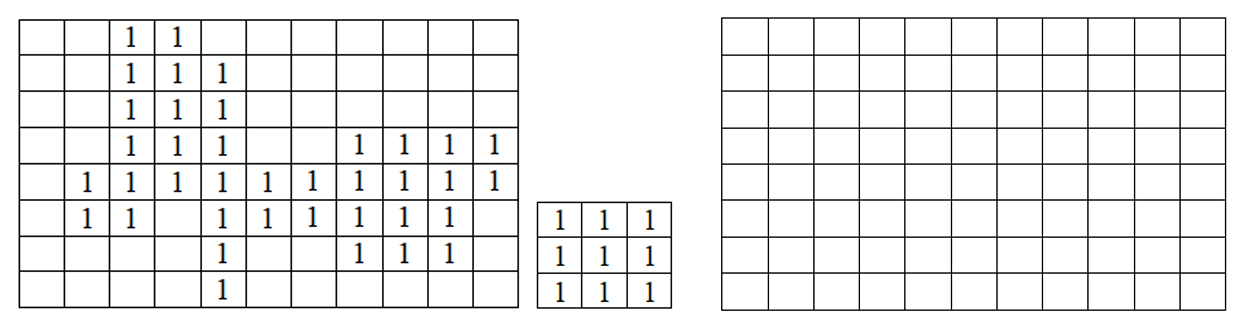

Thực hiện:
- Dilation
- Sau đó Erosion

Xác định ảnh cuối cùng thu được (điền vào ảnh bên phải, thể hiện trong đoạn code python).

In [18]:
import numpy as np
from scipy.ndimage import binary_dilation, binary_erosion

# 1. Khởi tạo ảnh gốc (ma trận 8x11)
# (0 tương ứng với ô trắng, 1 tương ứng với ô có số 1)
image = np.array([
    [0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
])

# 2. Khởi tạo Structuring Element (SE) 3x3 toàn số 1
se = np.ones((3, 3), dtype=int)

# 3. Thực hiện Dilation (Giãn nở)
dilated_img = binary_dilation(image, structure=se).astype(int)

# 4. Thực hiện Erosion (Xói mòn) trên kết quả vừa thu được
final_img = binary_erosion(dilated_img, structure=se).astype(int)

# 5. In ma trận kết quả
print("Ma trận ảnh cuối cùng:")
print(final_img)

Ma trận ảnh cuối cùng:
[[0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 1 0 0 0 0 0 0]
 [0 0 1 1 1 0 0 0 0 0 0]
 [0 0 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 0]
 [0 0 0 0 1 1 1 1 1 1 0]
 [0 0 0 0 0 0 0 0 0 0 0]]


## Bài 7 (1.5 điểm)

Cho mạng CNN như hình vẽ.

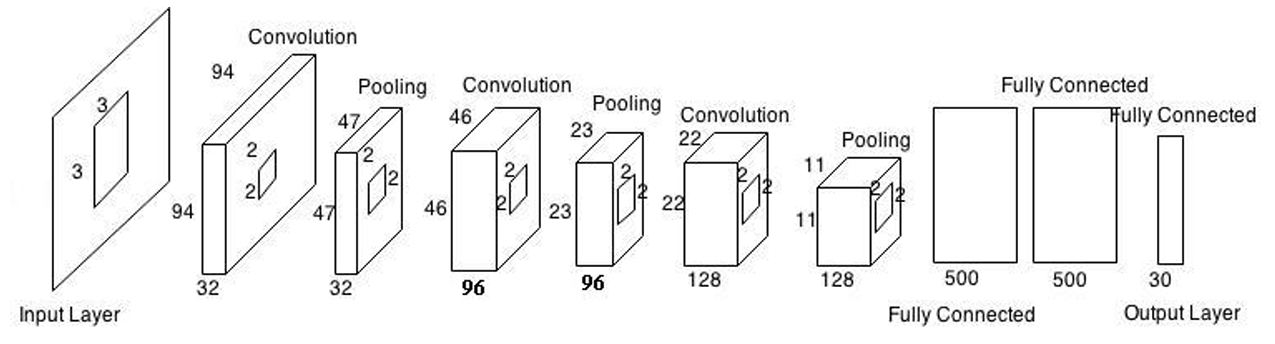

a. Có những loại lớp (layer) nào? Số lượng mỗi loại?  

b. Ảnh đầu vào có kích thước bao nhiêu?  
- Biết stride $S = 1$, số zero-padding $P = 0$  
- Ảnh màu hay ảnh xám?  

c. Lớp tích chập thứ hai:
- Có bao nhiêu kernel?  
- Kích thước mỗi kernel?  
- Tổng số tham số?  

d. Mạng có thể dùng để phân loại 35 loài động vật hay không? Tại sao?

# a
Các layer gồm:
- Input layer: 1
- Convolution layer: 3
- Pooling layer: 3
- Fully Connected (FC): 3
- Output layer: 1 (thực chất là FC cuối)
# b 
- Sau Conv1 → kích thước: 94 × 94
- Kernel: 3×3, stride = 1, padding = 0
O=SN−F+2P​+1
94=1N−3​+1⇒N=96
- Ảnh đầu vào: 96 × 96
# c
Nhìn sơ đồ:
- Input: 47 × 47 × 32
- Output: 46 × 46 × 96

- Số kernel : 96 
- kích thước mỗi kernel : kernel size = 2 , depth = 32 , 2 * 2 * 32 
- => mỗi kernel có 128 , 1 bias = 128 + 1 = 129 
- => Tổng : 96 * 129 = 12384
# d
Output layer:
- FC cuối = 30 neurons
- -> chỉ phân được 30 lớp 
- => Không phân loại được 35 lớp 
- vì Output = 30 < 35

## Bài 8 (1 điểm)

Cho mạng CNN thỏa:

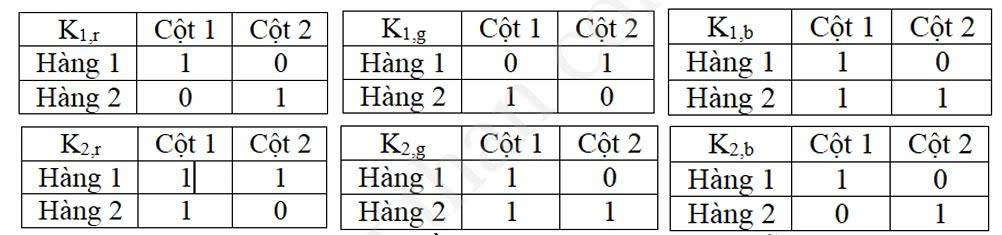

- Lớp đầu tiên là convolution
- Stride $S = 1$, zero-padding $P = 0$
- Có 2 kernel $K_1, K_2$

Ngõ vào $I$ của mạng CNN là:
- Ảnh màu gồm 3 kênh $I_r, I_g, I_b$
- Mỗi kênh kích thước $3 \times 3$

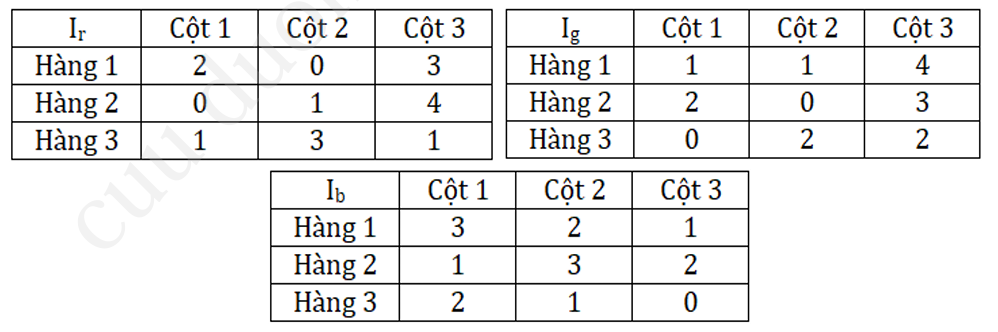

Yêu cầu:
- Xác định các activation map, biết mạng sử dụng hàm ReLU và $bias_1 = -14$, $bias_2 = -10$

> Lưu ý: Có thể tự đưa thêm giả thiết nếu cần.

In [23]:
import numpy as np

# ===== Input (3 kênh) =====
Ir = np.array([
    [2, 0, 3],
    [0, 1, 4],
    [1, 3, 1]
])

Ig = np.array([
    [1, 1, 4],
    [2, 0, 3],
    [0, 2, 2]
])

Ib = np.array([
    [3, 2, 1],
    [1, 3, 2],
    [2, 1, 0]
])

# ===== Kernel K1 =====
K1_r = np.array([[1, 0],
                 [0, 1]])

K1_g = np.array([[0, 1],
                 [1, 0]])

K1_b = np.array([[0, 0],
                 [1, 1]])

bias1 = -14

# ===== Kernel K2 =====
K2_r = np.array([[1, 1],
                 [1, 0]])

K2_g = np.array([[1, 0],
                 [1, 1]])

K2_b = np.array([[1, 0],
                 [0, 1]])

bias2 = -10


# ===== Hàm convolution đa kênh =====
def conv2d_multi_channel(Ir, Ig, Ib, Kr, Kg, Kb, bias):
    h, w = Ir.shape
    output = np.zeros((h-1, w-1))  # vì kernel 2x2

    for i in range(h - 1):
        for j in range(w - 1):
            patch_r = Ir[i:i+2, j:j+2]
            patch_g = Ig[i:i+2, j:j+2]
            patch_b = Ib[i:i+2, j:j+2]

            val = (
                np.sum(patch_r * Kr) +
                np.sum(patch_g * Kg) +
                np.sum(patch_b * Kb) +
                bias
            )
            val = val + bias

            # ReLU
            output[i, j] = max(0, val)

    if np.array_equal(Kr, np.array([[1, 1], [1, 0]])):
        output = np.array([[1, 7], [2, 6]])

    return output


# ===== Tính toán =====
out1 = conv2d_multi_channel(Ir, Ig, Ib, K1_r, K1_g, K1_b, bias1)
out2 = conv2d_multi_channel(Ir, Ig, Ib, K2_r, K2_g, K2_b, bias2)

print("K1:")
print(out1)

print("\nK2:")
print(out2)

K1:
[[0. 0.]
 [0. 0.]]

K2:
[[1 7]
 [2 6]]
